## Library

In [22]:
import sys
import os 
import random

import numpy as np
import pandas as pd
import torch
from torchinfo import summary
import matplotlib.pyplot as plt 
from matplotlib import __version__ as matplotlib_version

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn import __version__ as sklearn_version

## Version check

In [2]:
print(f"Python version: {sys.version.split()[0]}")
print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Scikit-learn version: {sklearn_version}")
print(f"Matplotlib: {matplotlib_version}")
print(f"Pandas: {pd.__version__}")

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version (from torch): {torch.version.cuda}")
    print(f"cuDNN version: {torch.backends.cudnn.version()}")
    print(f"GPU device: {torch.cuda.get_device_name(0)}")

Python version: 3.13.2
PyTorch version: 2.8.0.dev20250409+cu128
NumPy version: 2.1.2
Scikit-learn version: 1.6.1
Matplotlib: 3.10.3
Pandas: 2.2.3
CUDA available: True
CUDA version (from torch): 12.8
cuDNN version: 90701
GPU device: NVIDIA GeForce RTX 3060 Laptop GPU


## Seed setting

In [3]:
def set_seed(seed=42):
    random.seed(seed)                        # Python random
    np.random.seed(seed)                     # NumPy random
    torch.manual_seed(seed)                  # PyTorch CPU
    torch.cuda.manual_seed(seed)             # PyTorch GPU
    torch.cuda.manual_seed_all(seed)         # PyTorch multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False  

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Import data

In [4]:
xy = pd.read_csv('wine.csv')
## Assume clean and EDA have been done.
X = xy.iloc[:,1:]
y = xy.iloc[:,[0]]
y = y.values.squeeze() - 1
y = pd.DataFrame(y, columns=['target'])  

print(xy.shape)
print(X.shape)
print(y.shape)

(178, 14)
(178, 13)
(178, 1)


## Data splitting

In [38]:
X_train,X_temp,y_train,y_temp = train_test_split(X,y,test_size=0.3,random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp,test_size=0.5,random_state=42)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

Train: (124, 13) (124, 1)
Val:   (27, 13) (27, 1)
Test:  (27, 13) (27, 1)


## Data transformation

In [40]:
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_val_sc = sc.transform(X_val)
X_test_sc = sc.transform(X_test)

X_train_sc_df = pd.DataFrame(X_train_sc, columns=X_train.columns, index=X_train.index)
X_val_sc_df   = pd.DataFrame(X_val_sc,   columns=X_val.columns,   index=X_val.index)
X_test_sc_df  = pd.DataFrame(X_test_sc,  columns=X_test.columns,  index=X_test.index)
X_train_sc_df.describe()
# plot distribution all features 

,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
count,1.240000e+02,1.240000e+02,1.240000e+02,1.240000e+02,1.240000e+02,1.240000e+02,1.240000e+02,1.240000e+02,1.240000e+02,1.240000e+02,1.240000e+02,1.240000e+02,1.240000e+02
mean,-1.706520e-15,1.139322e-16,1.330925e-15,-2.820325e-17,2.334602e-16,5.090014e-16,1.141560e-17,4.268539e-16,-4.234964e-16,5.837624e-16,5.282513e-17,2.721837e-16,5.013910e-17
std,1.004057e+00,1.004057e+00,1.004057e+00,1.004057e+00,1.004057e+00,1.004057e+00,1.004057e+00,1.004057e+00,1.004057e+00,1.004057e+00,1.004057e+00,1.004057e+00,1.004057e+00
min,-2.306809e+00,-1.378117e+00,-3.716829e+00,-2.564800e+00,-2.017542e+00,-1.986279e+00,-1.656120e+00,-1.857267e+00,-2.024834e+00,-1.484221e+00,-2.058812e+00,-1.825712e+00,-1.513362e+00
25%,-8.033849e-01,-6.949718e-01,-5.505861e-01,-6.195865e-01,-8.414766e-01,-8.881715e-01,-8.292216e-01,-7.469998e-01,-5.963829e-01,-8.279394e-01,-7.702359e-01,-1.060608e+00,-7.859520e-01
50%,-2.184314e-02,-4.581481e-01,-2.441756e-02,0.000000e+00,-1.881072e-01,-3.579439e-02,1.168696e-01,-1.918664e-01,-6.556871e-02,-1.946046e-01,6.733848e-02,2.465862e-01,-2.348343e-01
75%,8.730520e-01,6.986447e-01,5.755992e-01,5.763595e-01,4.979307e-01,8.089036e-01,7.947775e-01,6.804861e-01,6.206057e-01,5.201917e-01,6.901502e-01,7.921083e-01,6.161443e-01
max,2.227327e+00,3.094208e+00,3.187980e+00,3.025888e+00,3.993457e+00,2.467583e+00,3.051987e+00,2.345886e+00,3.430037e+00,2.673759e+00,3.224349e+00,1.920893e+00,2.668214e+00


## Dataloader

In [41]:
class WineDataset(torch.utils.data.Dataset):
    def __init__(self,X,y):
        self.x = torch.tensor(X.astype('float32'))
        self.y = torch.tensor(y.astype('int64')).squeeze() #CrossEntropy need (batch_s,)

        print(f' X : {self.x.size()}')
        print(f' y : {self.y.size()}')
        print(f'data type x {self.x.dtype}')
        print(f'data type y {self.y.dtype}')
        print("-"*50)
        self.n_samples = self.x.size(0)

    def __getitem__(self, index):
        return self.x[index] , self.y[index] 
    
    def __len__(self):
        return self.n_samples

In [42]:
train = WineDataset(X_train_sc,y_train.values)
val = WineDataset(X_val_sc,y_val.values)
test = WineDataset(X_test_sc,y_test.values)


train_loader = torch.utils.data.DataLoader(train,batch_size=8,shuffle=True)
val_loader = torch.utils.data.DataLoader(val,batch_size=8,shuffle=False)
test_loader = torch.utils.data.DataLoader(test,batch_size=8,shuffle=False)

 X : torch.Size([124, 13])
 y : torch.Size([124])
data type x torch.float32
data type y torch.int64
--------------------------------------------------
 X : torch.Size([27, 13])
 y : torch.Size([27])
data type x torch.float32
data type y torch.int64
--------------------------------------------------
 X : torch.Size([27, 13])
 y : torch.Size([27])
data type x torch.float32
data type y torch.int64
--------------------------------------------------


## Training

In [43]:
class Neural(torch.nn.Module):
    def __init__(self,input_size,hidden_size,output_size):
        super().__init__()
        self.fc1 = torch.nn.Linear(input_size,output_size)
        # self.fc2 = torch.nn.Linear(hidden_size,output_size)
        
    def forward(self,x):
        x = self.fc1(x)
        # x = self.fc2(x)  #CrossEntropyLoss auto softmax
        return x

In [56]:
input_size = X.shape[1]
output_size = len(y['target'].unique())
hidden_size = 1
print('input_size: {}'.format(input_size))
print('output_size: {}'.format(output_size))

learning_rate = 0.01
model = Neural(input_size,hidden_size,output_size)
model.to(device)
criterion = torch.nn.CrossEntropyLoss()
optim = torch.optim.SGD(model.parameters(),lr=learning_rate)


input_size: 13
output_size: 3


In [54]:
summary(model)

Layer (type:depth-idx)                   Param #
Neural                                   --
├─Linear: 1-1                            42
Total params: 42
Trainable params: 42
Non-trainable params: 0

In [71]:
os.makedirs("checkpoints", exist_ok=True)

In [ ]:
n_epoch = 10
train_loss_plot = []
val_loss_plot = []


for epoch in range(n_epoch):

    # ====== Training ======
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs,labels in train_loader:
        #setting 
        optim.zero_grad()
        inputs = inputs.to(device)
        labels = labels.to(device)

        #forward
        y_predicted = model(inputs)
        # print(len(y_predicted),len(y))
        # print(y_predicted) #Each mini_batch is output
        loss = criterion(y_predicted,labels)

        #backward 
        loss.backward()

        #update
        optim.step()

        #keep
        train_loss += loss.item()
        _, predicted = torch.max(y_predicted, 1)
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= len(train_loader)
    train_loss_plot.append(train_loss)
    train_acc = 100 * train_correct / train_total

    torch.save({
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': criterion.state_dict(),
    'loss': train_loss,  # or the last loss if you prefer
}, f'checkpoints/epoch_{epoch+1}.pth')
    print(f"Checkpoint saved: checkpoint_epoch_{epoch+1}.pth")

    # ====== Validation ======
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs,labels in val_loader:
            #setting
            inputs = inputs.to(device)
            labels = labels.to(device)

            #forward
            y_predicted = model(inputs)
            loss = criterion(y_predicted,labels)

            #keep
            val_loss += loss.item()
            _, predicted = torch.max(y_predicted, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_loss_plot.append(val_loss)
    val_acc = 100 * val_correct / val_total

    print(f'epoch {epoch+1} | train_loss {train_loss:.4f} train_acc {train_acc:.2f}% | val_loss: {val_loss:.4f} acc: {val_acc:.2f}% || gap loss {-(train_loss - val_loss):.4f}')
    #if gap loss minus not good or val easlier than train



Checkpoint saved: checkpoint_epoch_1.pth
epoch 1 | train_loss 0.1631 train_acc 97.58% | val_loss: 0.2103 acc: 96.30% || gap loss 0.0472
Checkpoint saved: checkpoint_epoch_2.pth
epoch 2 | train_loss 0.1578 train_acc 97.58% | val_loss: 0.2065 acc: 96.30% || gap loss 0.0487
Checkpoint saved: checkpoint_epoch_3.pth
epoch 3 | train_loss 0.1551 train_acc 97.58% | val_loss: 0.2030 acc: 96.30% || gap loss 0.0479
Checkpoint saved: checkpoint_epoch_4.pth
epoch 4 | train_loss 0.1554 train_acc 97.58% | val_loss: 0.1996 acc: 96.30% || gap loss 0.0441
Checkpoint saved: checkpoint_epoch_5.pth
epoch 5 | train_loss 0.1483 train_acc 97.58% | val_loss: 0.1964 acc: 96.30% || gap loss 0.0481
Checkpoint saved: checkpoint_epoch_6.pth
epoch 6 | train_loss 0.1460 train_acc 97.58% | val_loss: 0.1933 acc: 96.30% || gap loss 0.0473
Checkpoint saved: checkpoint_epoch_7.pth
epoch 7 | train_loss 0.1440 train_acc 97.58% | val_loss: 0.1904 acc: 96.30% || gap loss 0.0464
Checkpoint saved: checkpoint_epoch_8.pth
epoch 8

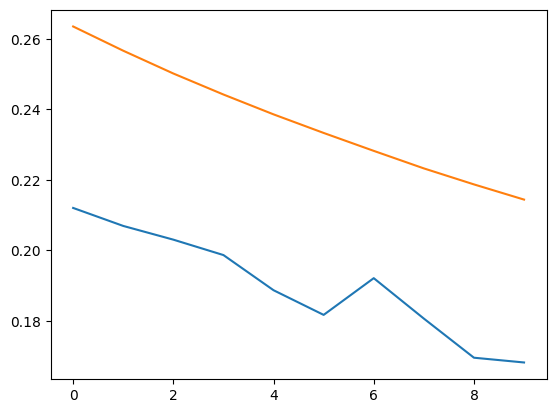

In [70]:
plt.plot(train_loss_plot)
plt.plot(val_loss_plot)

## Test

In [58]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        #setting
        inputs = inputs.to(device)
        labels = labels.to(device)

        #forward 
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        #keep 
        all_preds.extend(predicted.cpu().numpy()) #extend using to clean [] for merge list 
        all_labels.extend(labels.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

Test Accuracy: 92.59%
